# SARIMAX 06B — Rolling Evaluation

Load the previously generated **SARIMAX rolling-origin** outputs and evaluate the model without retraining.

This notebook follows the same evaluation structure used for the XGBoost and LightGBM forecasting candidates, including:

- global, fold, FSA, and horizon metrics;
- Actual vs Predicted diagnostics;
- residual analysis;
- temporal validation timelines;
- monthly error analysis;
- FSA × Month diagnostics;
- FSA × Fold and FSA × Horizon heatmaps;
- M9W-2023 stress-case analysis;
- error analysis by temperature band.

The final 2025 holdout remains untouched.

In [1]:
# Import libraries
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Define project paths
PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "forecasting"
    / "sarimax_rolling"
)

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "modeling"
    / "forecasting"
    / "sarimax_rolling"
)

REPORTS_DIR, OUTPUTS_DIR


(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/forecasting/sarimax_rolling'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/sarimax_rolling'))

In [4]:
# Load saved SARIMAX rolling metrics and validation predictions.
# This notebook does not retrain the model.

global_metrics = pd.read_csv(
    REPORTS_DIR / "SARIMAX_ROLLING_06_global_metrics.csv"
)

fold_metrics = pd.read_csv(
    REPORTS_DIR / "SARIMAX_ROLLING_06_fold_metrics.csv"
)

fsa_metrics = pd.read_csv(
    REPORTS_DIR / "SARIMAX_ROLLING_06_fsa_metrics.csv"
)

horizon_metrics = pd.read_csv(
    REPORTS_DIR / "SARIMAX_ROLLING_06_horizon_metrics.csv"
)

fit_diagnostics = pd.read_csv(
    REPORTS_DIR / "SARIMAX_ROLLING_fit_diagnostics.csv"
)

predictions = pd.read_parquet(
    OUTPUTS_DIR / "sarimax_rolling_validation_predictions.parquet"
)

predictions["forecast_origin"] = pd.to_datetime(
    predictions["forecast_origin"]
)

predictions["residual"] = (
    predictions["actual"] - predictions["predicted"]
)

predictions["absolute_error"] = predictions["residual"].abs()

predictions["absolute_percentage_error"] = np.where(
    predictions["actual"] != 0,
    predictions["absolute_error"]
    / predictions["actual"].abs()
    * 100,
    np.nan,
)

predictions["year"] = predictions["forecast_origin"].dt.year
predictions["month_number"] = predictions["forecast_origin"].dt.month
predictions["month_name"] = predictions["forecast_origin"].dt.strftime("%b")

print(f"Validation rows loaded: {len(predictions):,}")
print(f"FSAs: {sorted(predictions['fsa'].dropna().unique())}")
print(f"Folds: {sorted(predictions['fold'].dropna().unique())}")


Validation rows loaded: 2,519,424
FSAs: ['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9W']
Folds: ['fold_2023', 'fold_2024']


## Global Metrics

In [5]:
display(global_metrics)

,model,mae,rmse,mape,wape,bias,n_observations
0,sarimax_rolling,583.635455,929.486636,6.089956,6.41415,-164.621729,2519424


## Metrics by Validation Fold

In [6]:
display(fold_metrics)

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,598.344296,953.983324,6.190622,6.630155,-196.007804,1257984
1,fold_2024,568.966912,904.396505,5.989566,6.202236,-133.321644,1261440


## Metrics by FSA

In [7]:
display(fsa_metrics)

,fold,fsa,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,L4T,739.399434,1082.673678,6.325209,6.540192,17.666794,209664
1,fold_2023,M5R,408.750925,573.106729,5.418624,5.487048,15.730880,209664
2,fold_2023,M5S,201.527060,274.712669,5.045900,5.054687,16.923703,209664
3,fold_2023,M6G,594.389239,868.408794,5.007337,5.122516,-90.133716,209664
4,fold_2023,M9R,422.135878,638.764381,7.221032,7.615525,-72.601524,209664
5,fold_2023,M9W,1223.863238,1649.924439,8.125628,8.582971,-1063.632962,209664
6,fold_2024,L4T,797.240432,1164.756703,6.608964,6.854043,-61.539625,210240
7,fold_2024,M5R,410.772119,581.275533,5.440852,5.472865,8.767592,210240
8,fold_2024,M5S,204.576324,280.602830,5.142891,5.113790,10.980277,210240
9,fold_2024,M6G,610.690316,888.848892,5.148990,5.225657,-71.867603,210240


## Metrics by Forecast Horizon

In [8]:
display(horizon_metrics)

,fold,horizon,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,1,126.584597,186.626508,1.439845,1.402844,-11.996049,52416
1,fold_2023,2,234.877853,349.354675,2.623915,2.602957,-31.039289,52416
2,fold_2023,3,331.382923,495.048114,3.661770,3.672417,-53.466356,52416
3,fold_2023,4,411.926275,616.728130,4.509693,4.564976,-76.990814,52416
4,fold_2023,5,477.319209,715.605937,5.181603,5.289623,-100.220221,52416
5,fold_2023,6,527.820823,794.515589,5.680901,5.849230,-122.341479,52416
6,fold_2023,7,564.961431,855.299659,6.027295,6.260758,-142.915616,52416
7,fold_2023,8,590.069474,900.730963,6.224608,6.538934,-161.742226,52416
8,fold_2023,9,606.069240,934.319069,6.311945,6.716157,-178.795127,52416
9,fold_2023,10,617.754634,960.777846,6.357930,6.845546,-194.127558,52416


## SARIMAX Fit Diagnostics

In [9]:
display(fit_diagnostics)

,fold,fsa,training_observations,validation_origins,forecast_rows,specification,requested_trend,implemented_trend,explicit_intercept_in_exog,converged,fit_seconds,iterations,convergence_warning_count,aic,bic,task_seconds,resumed_from_checkpoint
0,fold_2023,L4T,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,117.146457,64,0,240016.302638,240117.307610,188.088755,False
1,fold_2023,M5R,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,68.579175,32,0,225559.488045,225660.493017,137.153361,False
2,fold_2023,M5S,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,45.400665,23,0,203643.145559,203744.150532,114.381006,False
3,fold_2023,M6G,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,54.847965,32,0,235779.163958,235880.168930,125.110818,False
4,fold_2023,M9R,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,99.721255,67,0,228145.458441,228246.463414,168.057463,False
5,fold_2023,M9W,17520,8736,209664,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,93.066968,58,0,239950.229903,240051.234875,171.550297,False
6,fold_2024,L4T,26280,8760,210240,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,125.744056,56,0,358601.813878,358708.096336,218.067452,False
7,fold_2024,M5R,26280,8760,210240,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,137.941613,54,0,338670.975588,338777.258045,216.184814,False
8,fold_2024,M5S,26280,8760,210240,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,100.964099,26,0,305306.769936,305413.052393,245.104464,False
9,fold_2024,M6G,26280,8760,210240,"{'order': [2, 0, 1], 'seasonal_order': [1, 0, ...",c,n,True,True,158.087482,28,0,353715.326939,353821.609397,261.567204,False


### Fit-Convergence Summary

Before interpreting forecast accuracy, verify that the SARIMAX fits converged consistently and review runtime variability across FSA/fold tasks.

In [10]:
# Summarize fit convergence and runtime.
fit_summary = pd.DataFrame(
    [
        {
            "tasks": len(fit_diagnostics),
            "converged_tasks": int(fit_diagnostics["converged"].sum()),
            "non_converged_tasks": int((~fit_diagnostics["converged"].astype(bool)).sum()),
            "total_convergence_warnings": int(
                fit_diagnostics["convergence_warning_count"].sum()
            ),
            "mean_fit_seconds": fit_diagnostics["fit_seconds"].mean(),
            "median_fit_seconds": fit_diagnostics["fit_seconds"].median(),
            "max_fit_seconds": fit_diagnostics["fit_seconds"].max(),
            "mean_iterations": fit_diagnostics["iterations"].mean(),
        }
    ]
)

display(fit_summary)


,tasks,converged_tasks,non_converged_tasks,total_convergence_warnings,mean_fit_seconds,median_fit_seconds,max_fit_seconds,mean_iterations
0,12,12,0,0,102.239013,100.844101,158.087482,44.0


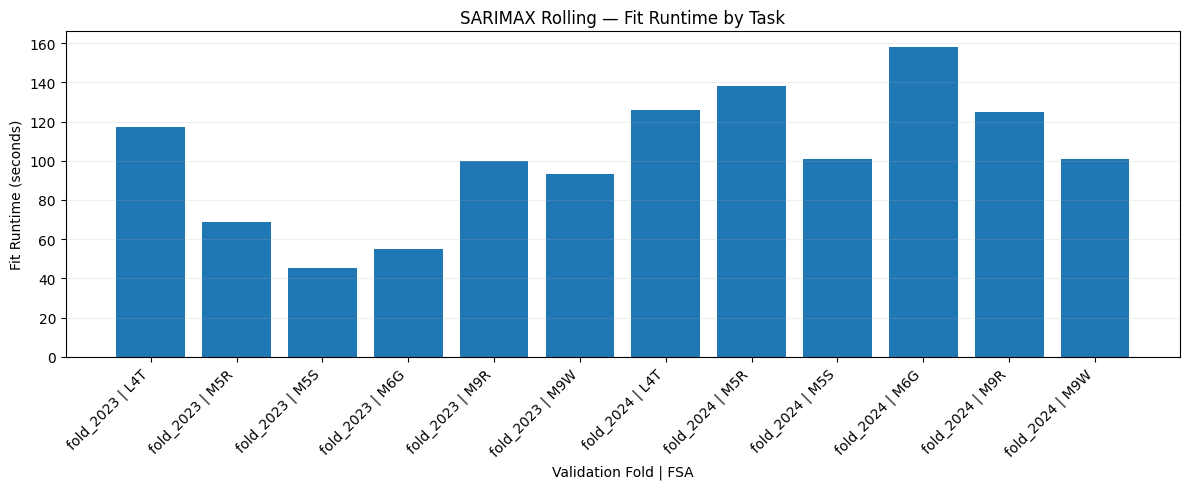

In [11]:
# Plot fit runtime by FSA and validation fold.
fit_runtime = fit_diagnostics.copy()

fit_runtime["task_label"] = (
    fit_runtime["fold"].astype(str)
    + " | "
    + fit_runtime["fsa"].astype(str)
)

plt.figure(figsize=(12, 5))

plt.bar(
    fit_runtime["task_label"],
    fit_runtime["fit_seconds"],
)

plt.xlabel("Validation Fold | FSA")
plt.ylabel("Fit Runtime (seconds)")
plt.title("SARIMAX Rolling — Fit Runtime by Task")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## Core Forecasting Diagnostics

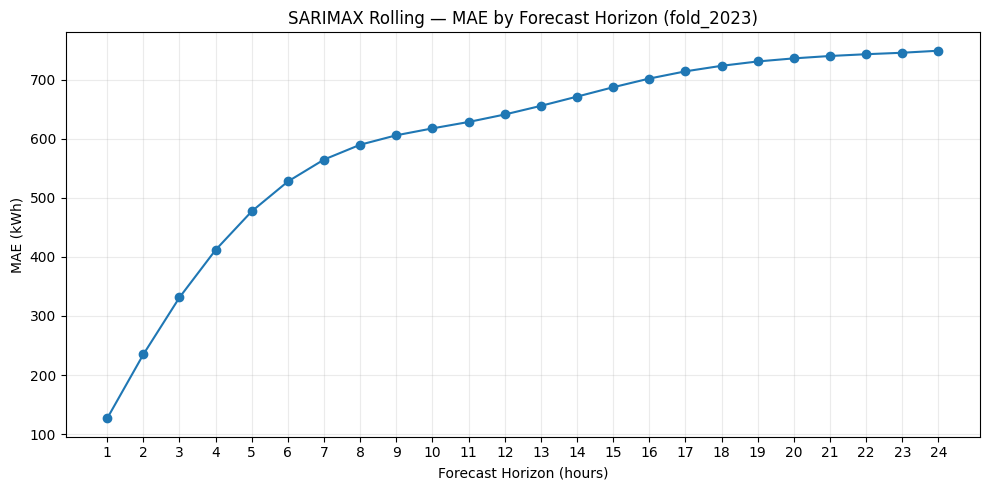

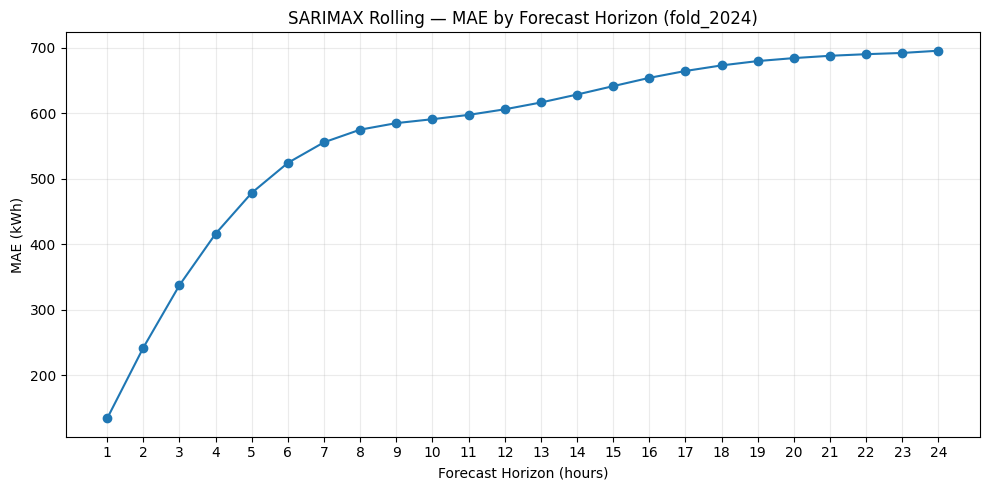

In [12]:
# MAE by forecast horizon.
for fold, group in horizon_metrics.groupby("fold", observed=True):
    group = group.sort_values("horizon")

    plt.figure(figsize=(10, 5))

    plt.plot(
        group["horizon"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(
        f"SARIMAX Rolling — MAE by Forecast Horizon ({fold})"
    )
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


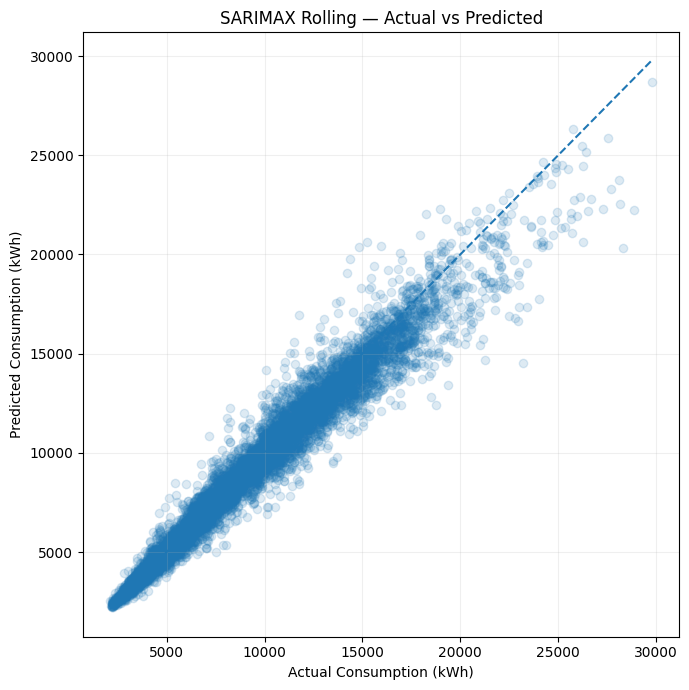

In [13]:
# Actual vs Predicted scatter plot.
sample = predictions.sample(
    n=min(10000, len(predictions)),
    random_state=42,
)

plt.figure(figsize=(7, 7))

plt.scatter(
    sample["actual"],
    sample["predicted"],
    alpha=0.15,
)

minimum = min(
    sample["actual"].min(),
    sample["predicted"].min(),
)

maximum = max(
    sample["actual"].max(),
    sample["predicted"].max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("SARIMAX Rolling — Actual vs Predicted")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


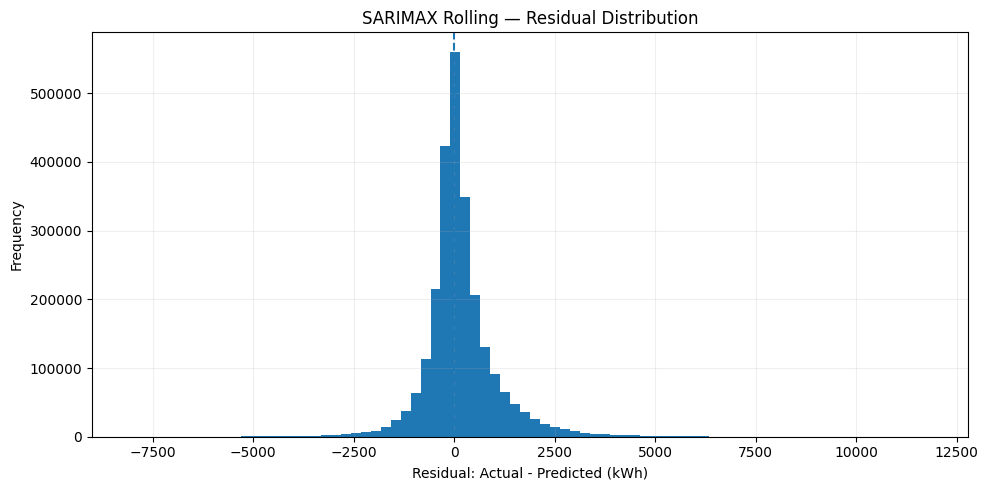

In [14]:
# Residual distribution.
plt.figure(figsize=(10, 5))

plt.hist(
    predictions["residual"].dropna(),
    bins=80,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel("Residual: Actual - Predicted (kWh)")
plt.ylabel("Frequency")
plt.title("SARIMAX Rolling — Residual Distribution")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


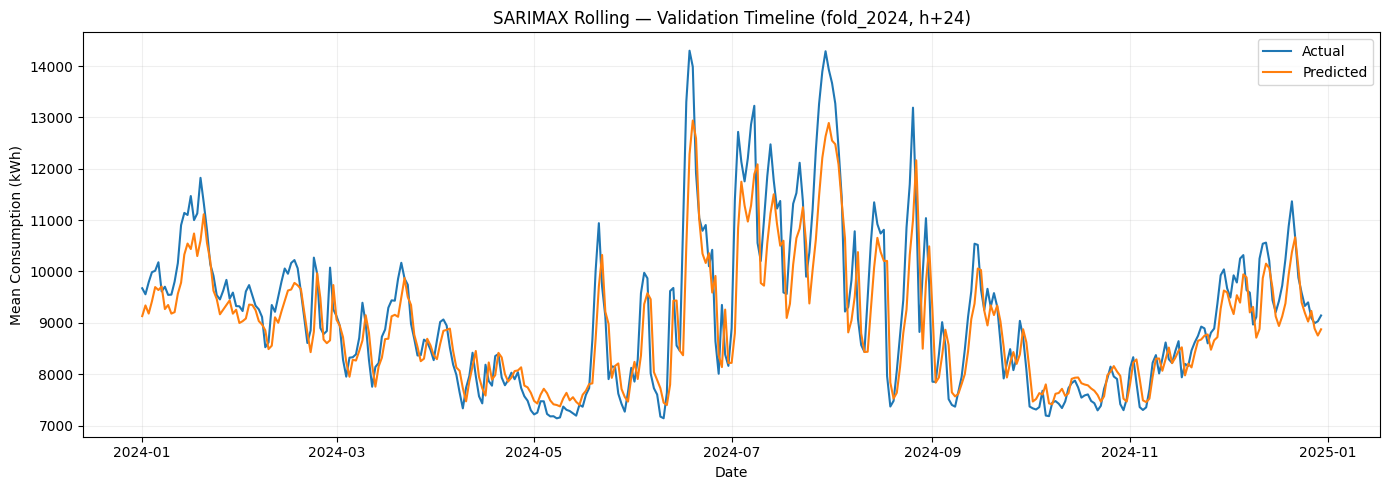

In [15]:
# Full validation timeline for fold_2024, h+24.
timeline = predictions.query(
    "fold == 'fold_2024' and horizon == 24"
).copy()

timeline["date"] = timeline["forecast_origin"].dt.floor("D")

daily = (
    timeline.groupby("date", observed=True)
    .agg(
        actual=("actual", "mean"),
        predicted=("predicted", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily["date"],
    daily["actual"],
    label="Actual",
)

plt.plot(
    daily["date"],
    daily["predicted"],
    label="Predicted",
)

plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")
plt.title(
    "SARIMAX Rolling — Validation Timeline "
    "(fold_2024, h+24)"
)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Additional Temporal and FSA Error Diagnostics

### Monthly metrics

In [16]:
# Calculate monthly validation metrics.
monthly_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "year",
            "month_number",
        ]
    )
)

display(monthly_metrics)


,fold,year,month_number,month_name,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Jan,107136,532.616314,5.127345,335.926020,9689.395584,9353.469564
1,fold_2023,2023,2,Feb,96768,608.838257,5.999135,291.428164,9756.330448,9464.902284
2,fold_2023,2023,3,Mar,107136,546.995705,5.719074,211.567787,9208.743095,8997.175308
3,fold_2023,2023,4,Apr,103680,475.535774,5.799512,37.473095,8088.189191,8050.716095
4,fold_2023,2023,5,May,107136,492.015013,6.036866,50.701277,7730.152050,7679.450772
5,fold_2023,2023,6,Jun,103680,678.919791,6.850892,173.909220,9050.545692,8876.636472
6,fold_2023,2023,7,Jul,107136,975.995015,8.248823,429.910948,10847.802063,10417.891115
7,fold_2023,2023,8,Aug,107136,765.721289,7.572496,227.397791,9338.000313,9110.602521
8,fold_2023,2023,9,Sep,103680,643.760643,6.730416,147.193312,8715.273743,8568.080431
9,fold_2023,2023,10,Oct,107136,459.386668,5.620158,29.782450,7912.513776,7882.731326


### Monthly MAE

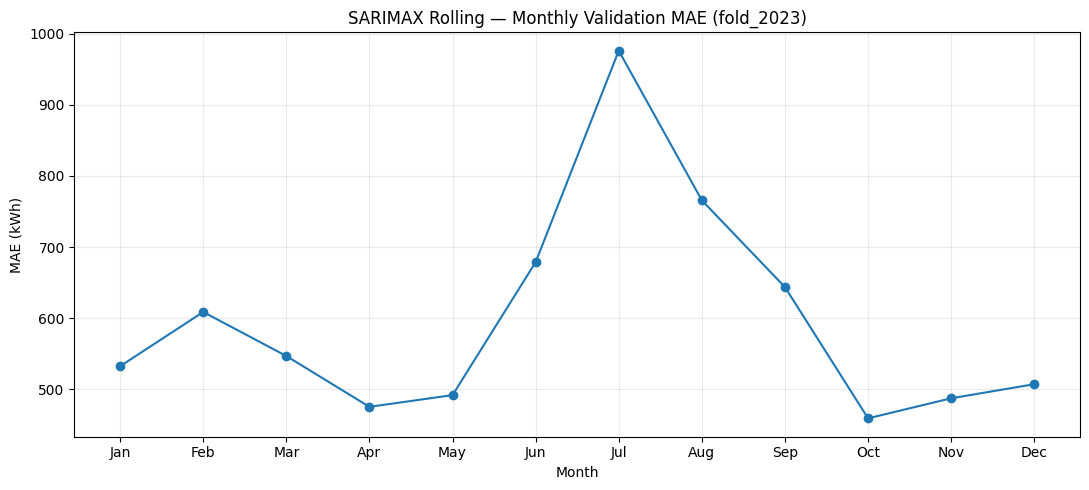

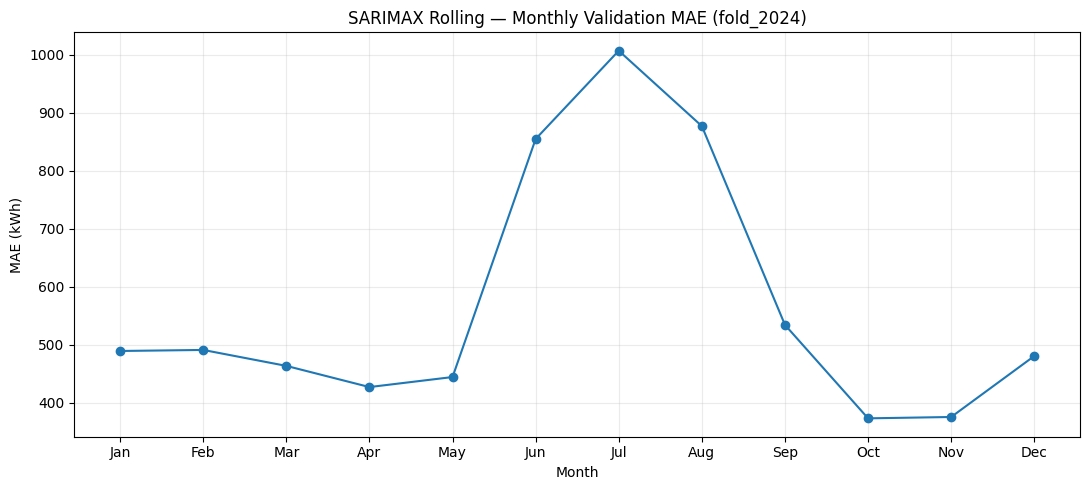

In [17]:
# Plot monthly MAE for each validation fold.
for fold, group in monthly_metrics.groupby("fold", observed=True):

    group = group.sort_values("month_number")

    plt.figure(figsize=(11, 5))

    plt.plot(
        group["month_name"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Month")
    plt.ylabel("MAE (kWh)")
    plt.title(
        f"SARIMAX Rolling — Monthly Validation MAE ({fold})"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### Monthly residual

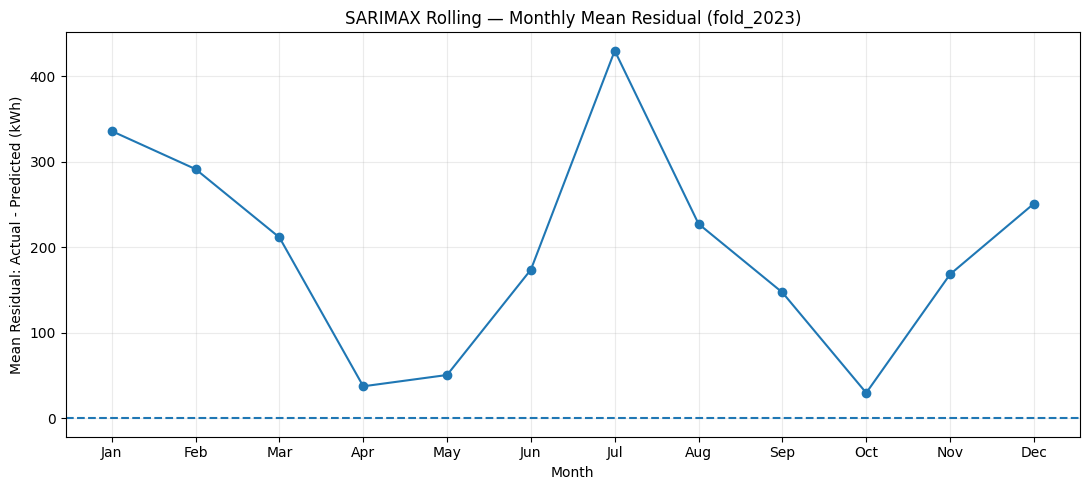

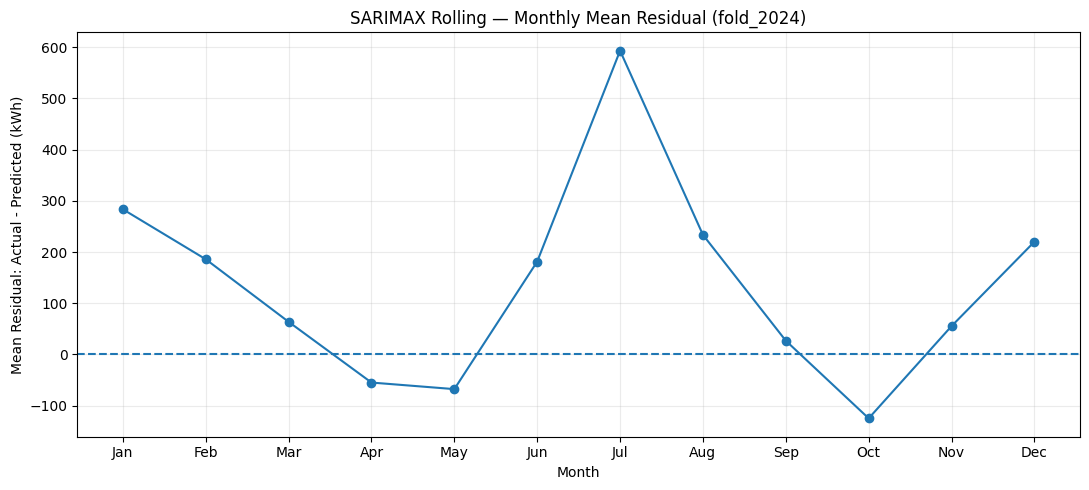

In [18]:
# Plot monthly mean residual.
for fold, group in monthly_metrics.groupby("fold", observed=True):

    group = group.sort_values("month_number")

    plt.figure(figsize=(11, 5))

    plt.plot(
        group["month_name"],
        group["mean_residual"],
        marker="o",
    )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xlabel("Month")
    plt.ylabel("Mean Residual: Actual - Predicted (kWh)")
    plt.title(
        f"SARIMAX Rolling — Monthly Mean Residual ({fold})"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### Monthly metrics × FSA

In [19]:
# Calculate monthly validation metrics by FSA.
monthly_fsa_metrics = (
    predictions
    .groupby(
        [
            "fold",
            "year",
            "month_number",
            "month_name",
            "fsa",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "fold",
            "fsa",
            "year",
            "month_number",
        ]
    )
)

display(monthly_fsa_metrics.head(30))


,fold,year,month_number,month_name,fsa,observations,mae,mape,mean_residual,actual_mean,predicted_mean
0,fold_2023,2023,1,Jan,L4T,17856,518.396435,4.507868,162.852133,11266.489830,11103.637697
6,fold_2023,2023,2,Feb,L4T,16128,577.717938,5.023114,119.055941,11317.397371,11198.341430
12,fold_2023,2023,3,Mar,L4T,17856,551.924916,5.056047,-36.565633,10798.958205,10835.523837
18,fold_2023,2023,4,Apr,L4T,17280,602.388596,6.080690,-297.985511,9954.833657,10252.819168
24,fold_2023,2023,5,May,L4T,17856,709.002535,7.020372,-283.700851,9962.615541,10246.316392
30,fold_2023,2023,6,Jun,L4T,17280,986.836900,8.043808,-43.295369,12019.116024,12062.411393
36,fold_2023,2023,7,Jul,L4T,17856,1285.803592,8.630909,365.031975,14512.347278,14147.315303
42,fold_2023,2023,8,Aug,L4T,17856,1073.709625,8.407179,71.222497,12565.724222,12494.501725
48,fold_2023,2023,9,Sep,L4T,17280,896.676795,7.482626,-48.697760,11511.567205,11560.264965
54,fold_2023,2023,10,Oct,L4T,17856,623.070860,6.206554,-280.289648,10010.141969,10290.431617


In [20]:
# Save monthly FSA diagnostics.
OUTPUT_PATH = (
    REPORTS_DIR
    / "SARIMAX_ROLLING_06_monthly_fsa_metrics.csv"
)

monthly_fsa_metrics.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved: {OUTPUT_PATH}")


Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\modeling\forecasting\sarimax_rolling\SARIMAX_ROLLING_06_monthly_fsa_metrics.csv


### Heatmap FSA × Month

In [21]:
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]


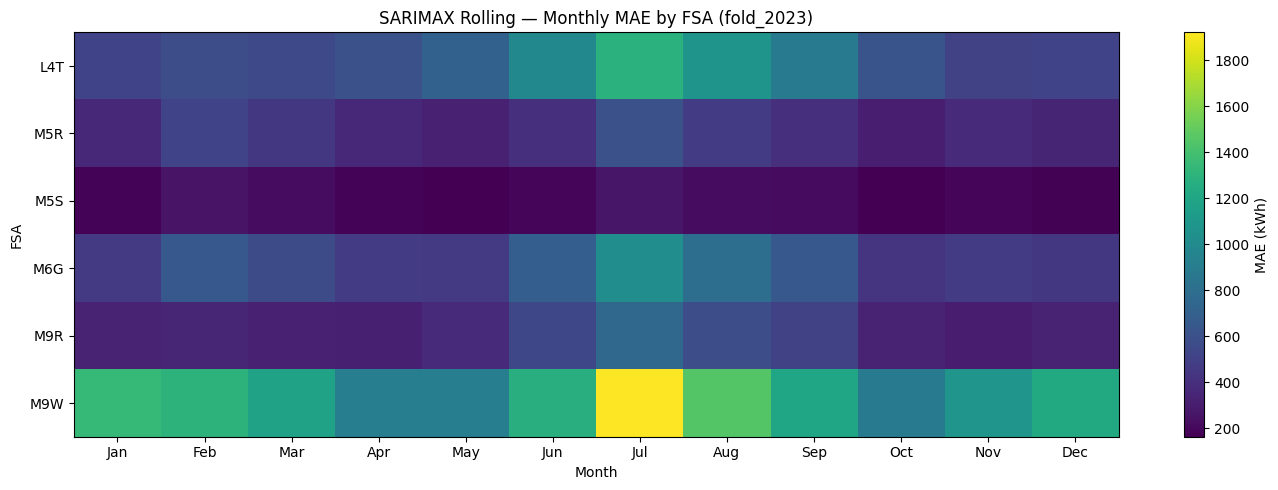

In [22]:
# Heatmap of monthly MAE by FSA — fold_2023.
heatmap_data = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"] == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
    .reindex(columns=range(1, 13))
)

plt.figure(figsize=(14, 5))

image = plt.imshow(
    heatmap_data.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")
plt.title(
    "SARIMAX Rolling — Monthly MAE by FSA (fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()


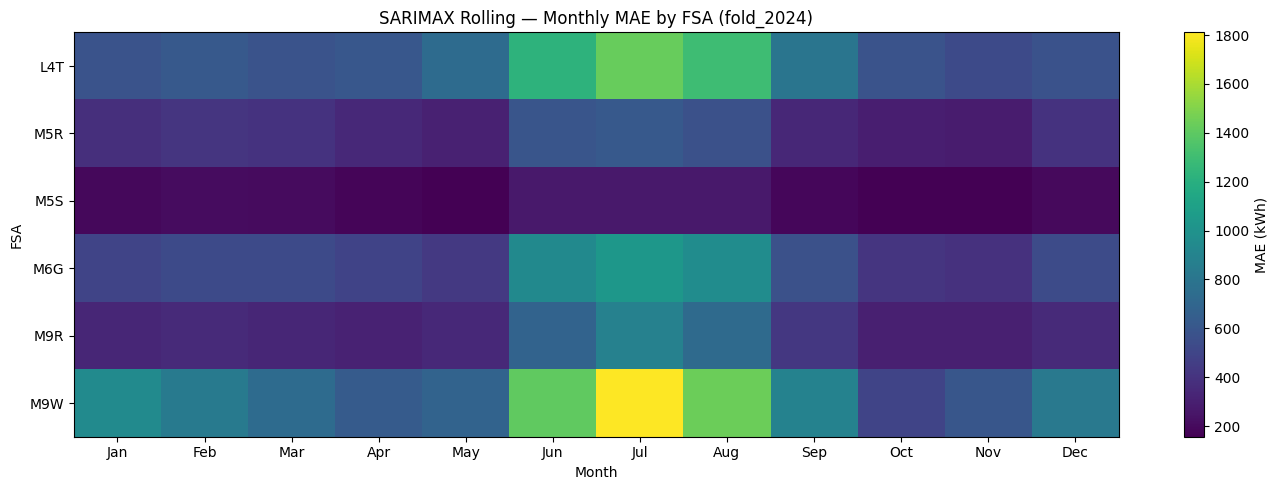

In [23]:
# Heatmap of monthly MAE by FSA — fold_2024.
heatmap_data = (
    monthly_fsa_metrics[
        monthly_fsa_metrics["fold"] == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="month_number",
        values="mae",
    )
    .reindex(columns=range(1, 13))
)

plt.figure(figsize=(14, 5))

image = plt.imshow(
    heatmap_data.values,
    aspect="auto",
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
)

plt.xticks(
    range(12),
    month_labels,
)

plt.xlabel("Month")
plt.ylabel("FSA")
plt.title(
    "SARIMAX Rolling — Monthly MAE by FSA (fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()


### Heatmap FSA × Fold

In [24]:
# Calculate MAE by FSA and validation fold.
fsa_fold_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(fsa_fold_mae)


,fold,fsa,mae
0,fold_2023,L4T,739.399434
1,fold_2023,M5R,408.750925
2,fold_2023,M5S,201.527060
3,fold_2023,M6G,594.389239
4,fold_2023,M9R,422.135878
5,fold_2023,M9W,1223.863238
6,fold_2024,L4T,797.240432
7,fold_2024,M5R,410.772119
8,fold_2024,M5S,204.576324
9,fold_2024,M6G,610.690316


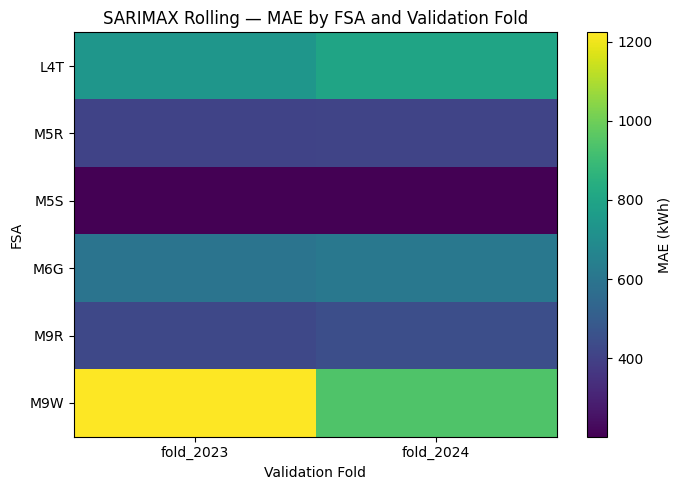

In [25]:
# Heatmap of MAE by FSA and fold.
fsa_fold_pivot = (
    fsa_fold_mae
    .pivot(
        index="fsa",
        columns="fold",
        values="mae",
    )
)

plt.figure(figsize=(7, 5))

image = plt.imshow(
    fsa_fold_pivot.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_fold_pivot.index)),
    fsa_fold_pivot.index,
)

plt.xticks(
    range(len(fsa_fold_pivot.columns)),
    fsa_fold_pivot.columns,
)

plt.xlabel("Validation Fold")
plt.ylabel("FSA")
plt.title(
    "SARIMAX Rolling — MAE by FSA and Validation Fold"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()


### FSA × Horizon

In [27]:
# Calculate MAE by FSA and forecast horizon.
fsa_horizon_mae = (
    predictions
    .groupby(
        [
            "fold",
            "fsa",
            "horizon",
        ],
        observed=True,
    )["absolute_error"]
    .mean()
    .reset_index(
        name="mae"
    )
)

display(fsa_horizon_mae.head())


,fold,fsa,horizon,mae
0,fold_2023,L4T,1,152.425365
1,fold_2023,L4T,2,294.824660
2,fold_2023,L4T,3,429.562379
3,fold_2023,L4T,4,541.889181
4,fold_2023,L4T,5,633.509579


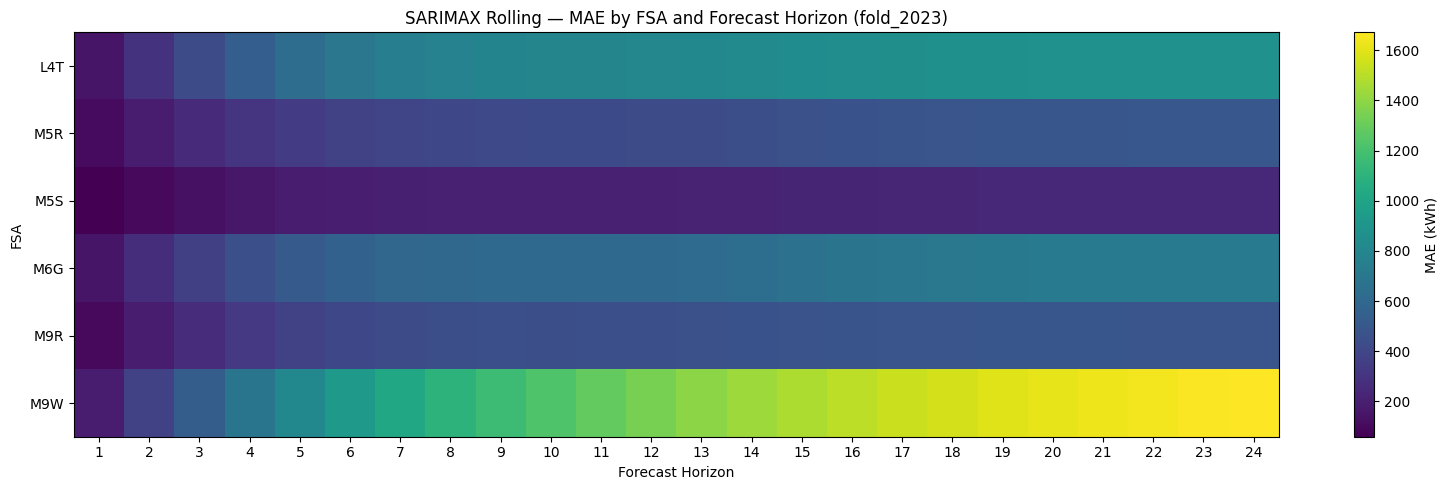

In [28]:
# Heatmap of MAE by FSA and forecast horizon — fold_2023.
fsa_horizon_data = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"] == "fold_2023"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
    .reindex(columns=range(1, 25))
)

plt.figure(figsize=(16, 5))

image = plt.imshow(
    fsa_horizon_data.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_data.index)),
    fsa_horizon_data.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel("Forecast Horizon")
plt.ylabel("FSA")
plt.title(
    "SARIMAX Rolling — MAE by FSA and Forecast Horizon "
    "(fold_2023)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()


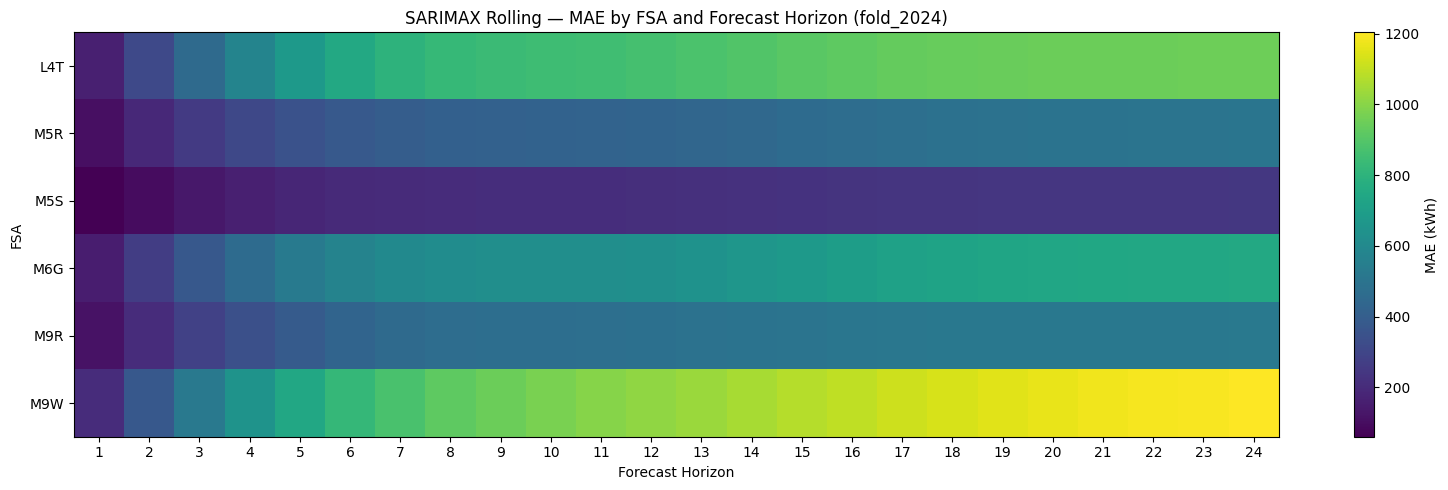

In [29]:
# Heatmap of MAE by FSA and forecast horizon — fold_2024.
fsa_horizon_data = (
    fsa_horizon_mae[
        fsa_horizon_mae["fold"] == "fold_2024"
    ]
    .pivot(
        index="fsa",
        columns="horizon",
        values="mae",
    )
    .reindex(columns=range(1, 25))
)

plt.figure(figsize=(16, 5))

image = plt.imshow(
    fsa_horizon_data.values,
    aspect="auto",
)

plt.yticks(
    range(len(fsa_horizon_data.index)),
    fsa_horizon_data.index,
)

plt.xticks(
    range(24),
    range(1, 25),
)

plt.xlabel("Forecast Horizon")
plt.ylabel("FSA")
plt.title(
    "SARIMAX Rolling — MAE by FSA and Forecast Horizon "
    "(fold_2024)"
)

plt.colorbar(
    image,
    label="MAE (kWh)",
)

plt.tight_layout()
plt.show()


### M9W-2023 analysis

In [30]:
# Isolate M9W during fold_2023.
m9w_2023 = (
    predictions[
        (
            predictions["fold"] == "fold_2023"
        )
        & (
            predictions["fsa"] == "M9W"
        )
    ]
    .copy()
)

print(
    f"M9W-2023 observations: {len(m9w_2023):,}"
)

display(m9w_2023.head())


M9W-2023 observations: 209,664


,fold,fsa,forecast_origin,horizon,actual,predicted,residual,absolute_error,absolute_percentage_error,year,month_number,month_name
1048320,fold_2023,M9W,2023-01-01,1,10386.7,10180.115071,206.584929,206.584929,1.988937,2023,1,Jan
1048321,fold_2023,M9W,2023-01-01,2,9824.2,9525.028351,299.171649,299.171649,3.045252,2023,1,Jan
1048322,fold_2023,M9W,2023-01-01,3,9433.5,9114.449157,319.050843,319.050843,3.382105,2023,1,Jan
1048323,fold_2023,M9W,2023-01-01,4,9162.5,8902.019387,260.480613,260.480613,2.842899,2023,1,Jan
1048324,fold_2023,M9W,2023-01-01,5,9096.0,8916.792470,179.207530,179.207530,1.970180,2023,1,Jan


In [31]:
# Summarize M9W-2023 error behavior.
m9w_2023_summary = pd.DataFrame(
    [
        {
            "observations": len(m9w_2023),
            "actual_mean": m9w_2023["actual"].mean(),
            "predicted_mean": m9w_2023["predicted"].mean(),
            "mae": m9w_2023["absolute_error"].mean(),
            "mape": m9w_2023["absolute_percentage_error"].mean(),
            "mean_residual": m9w_2023["residual"].mean(),
            "median_residual": m9w_2023["residual"].median(),
            "p95_absolute_error": (
                m9w_2023["absolute_error"].quantile(0.95)
            ),
            "maximum_absolute_error": (
                m9w_2023["absolute_error"].max()
            ),
        }
    ]
)

display(m9w_2023_summary)


,observations,actual_mean,predicted_mean,mae,mape,mean_residual,median_residual,p95_absolute_error,maximum_absolute_error
0,209664,14259.203217,13195.570255,1223.863238,8.125628,1063.632962,911.375808,3254.193997,8934.960497


### M9W monthly analysis

In [32]:
# Calculate monthly diagnostics for M9W during 2023.
m9w_2023_monthly = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
    .sort_values("month_number")
)

display(m9w_2023_monthly)


,month_number,month_name,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,1,Jan,17856,14738.861598,13432.413537,1338.301493,9.030292,1306.448061
1,2,Feb,16128,14916.540960,13659.693999,1299.800698,8.620086,1256.846960
2,3,Mar,17856,14345.509050,13225.503531,1177.037577,8.142578,1120.005519
3,4,Apr,17280,13025.586580,12197.283970,918.270473,6.946156,828.302610
4,5,May,17856,12669.597665,11856.934646,918.076683,6.716457,812.663019
5,6,Jun,17280,14427.741134,13434.813560,1266.621010,8.103028,992.927575
6,7,Jul,17856,16919.120934,15484.436897,1920.396606,10.532188,1434.684037
7,8,Aug,17856,14915.903584,13829.045352,1450.952594,9.066661,1086.858232
8,9,Sep,17280,13939.556667,13005.374997,1194.042656,7.673144,934.181670
9,10,Oct,17856,12769.972961,12002.990151,885.718364,6.629303,766.982810


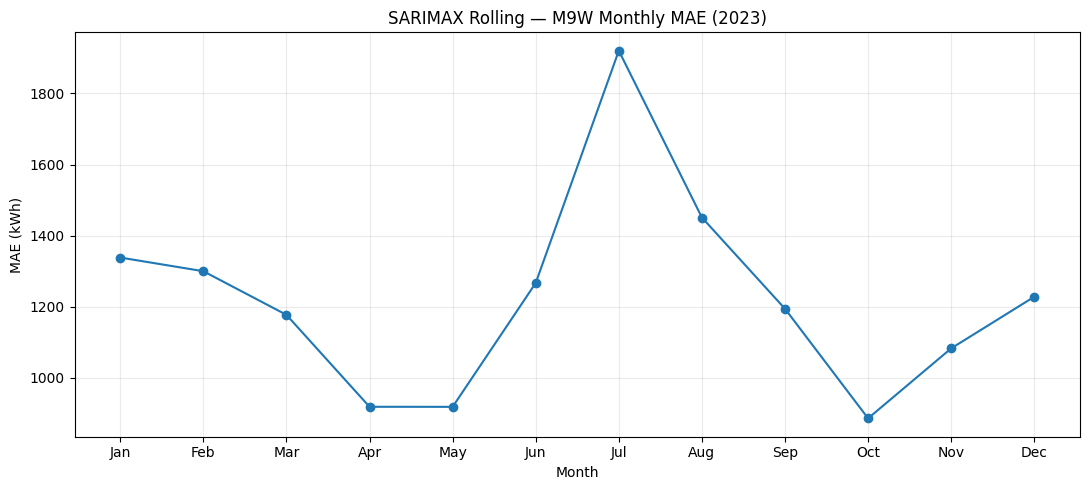

In [33]:
# Plot M9W-2023 monthly MAE.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mae"],
    marker="o",
)

plt.xlabel("Month")
plt.ylabel("MAE (kWh)")
plt.title(
    "SARIMAX Rolling — M9W Monthly MAE (2023)"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


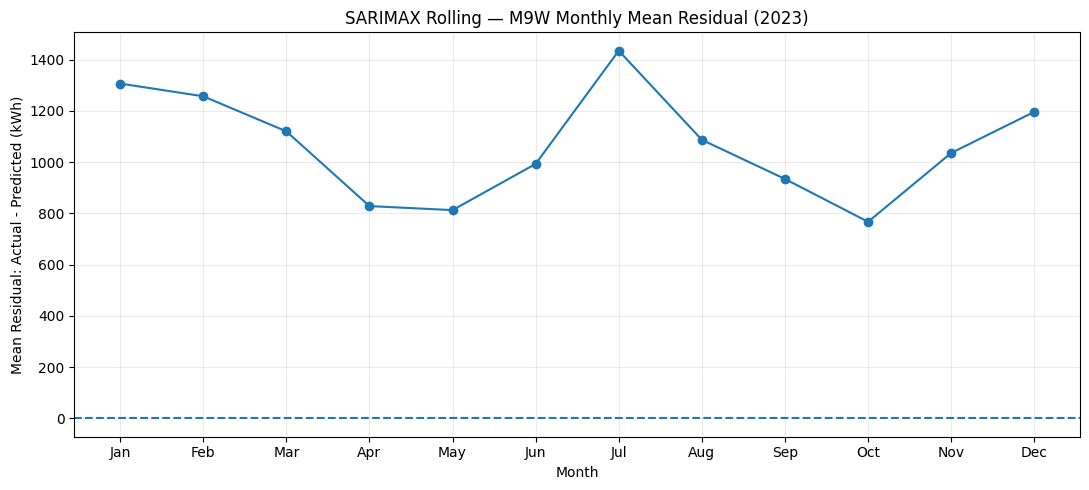

In [34]:
# Plot M9W-2023 monthly mean residual.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_2023_monthly["month_name"],
    m9w_2023_monthly["mean_residual"],
    marker="o",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Month")
plt.ylabel("Mean Residual: Actual - Predicted (kWh)")
plt.title(
    "SARIMAX Rolling — M9W Monthly Mean Residual (2023)"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### M9W Actual vs Predicted timeline

In [35]:
# Select h+24 for an interpretable M9W-2023 timeline.
m9w_h24 = (
    m9w_2023[
        m9w_2023["horizon"] == 24
    ]
    .sort_values("forecast_origin")
    .copy()
)

m9w_h24["date"] = (
    m9w_h24["forecast_origin"].dt.floor("D")
)

m9w_h24_daily = (
    m9w_h24
    .groupby(
        "date",
        observed=True,
    )
    .agg(
        actual=("actual", "mean"),
        predicted=("predicted", "mean"),
    )
    .reset_index()
)

display(m9w_h24_daily.head())


,date,actual,predicted
0,2023-01-01,12148.604167,11039.936289
1,2023-01-02,12896.716667,11130.389425
2,2023-01-03,14120.195833,11625.909579
3,2023-01-04,14381.362500,12445.932552
4,2023-01-05,14339.466667,12559.158763


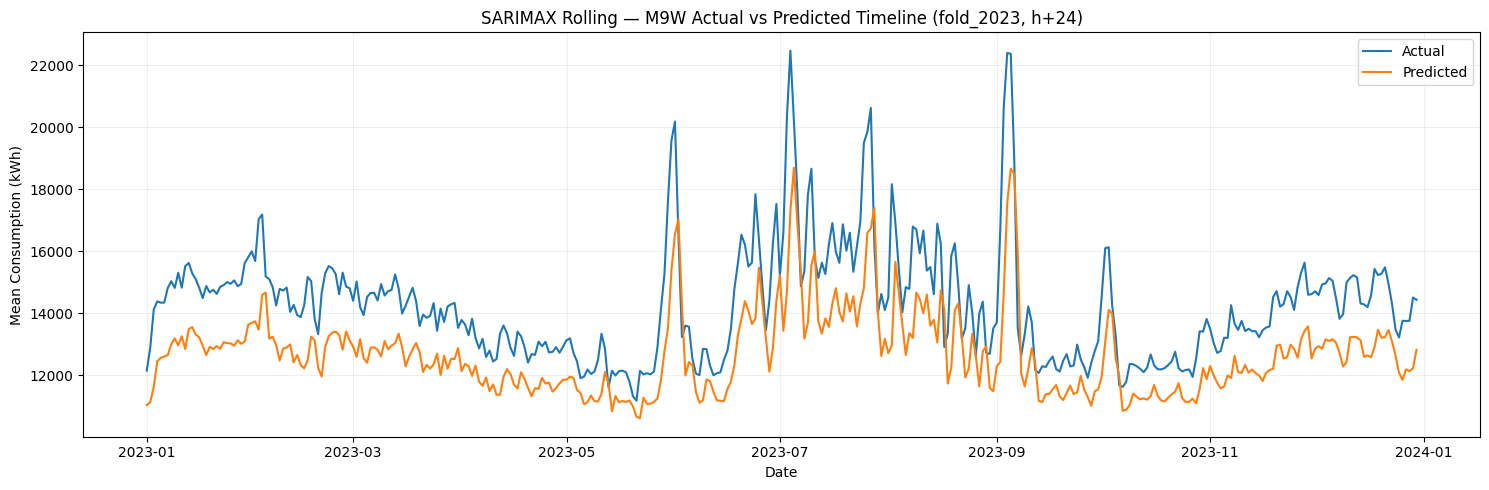

In [36]:
# Plot M9W-2023 Actual vs Predicted timeline.
plt.figure(figsize=(15, 5))

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["actual"],
    label="Actual",
)

plt.plot(
    m9w_h24_daily["date"],
    m9w_h24_daily["predicted"],
    label="Predicted",
)

plt.xlabel("Date")
plt.ylabel("Mean Consumption (kWh)")
plt.title(
    "SARIMAX Rolling — M9W Actual vs Predicted Timeline "
    "(fold_2023, h+24)"
)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### M9W residual timeline

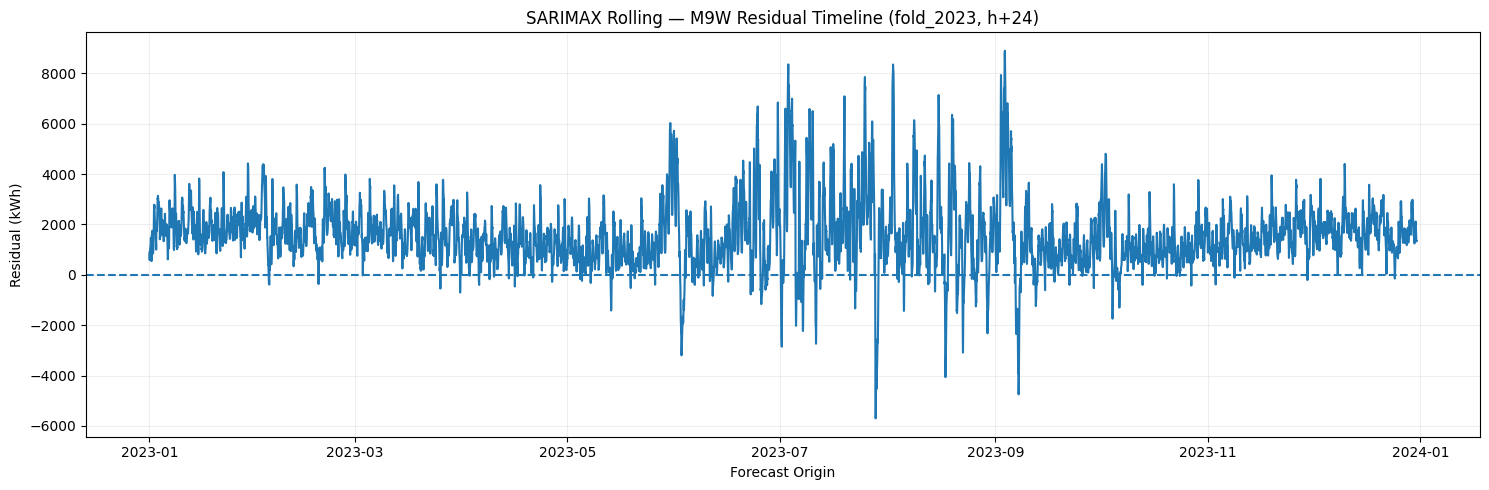

In [37]:
# Plot M9W-2023 residual timeline for h+24.
m9w_h24["residual"] = (
    m9w_h24["actual"] - m9w_h24["predicted"]
)

plt.figure(figsize=(15, 5))

plt.plot(
    m9w_h24["forecast_origin"],
    m9w_h24["residual"],
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Forecast Origin")
plt.ylabel("Residual (kWh)")
plt.title(
    "SARIMAX Rolling — M9W Residual Timeline "
    "(fold_2023, h+24)"
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Actual vs Predicted monthly level

In [38]:
# Compare actual and predicted monthly demand levels for M9W-2023.
m9w_level_comparison = (
    m9w_2023
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
    )
    .agg(
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
    )
    .reset_index()
    .sort_values("month_number")
)

m9w_level_comparison["difference_kwh"] = (
    m9w_level_comparison["actual_mean"]
    - m9w_level_comparison["predicted_mean"]
)

m9w_level_comparison["difference_pct"] = (
    m9w_level_comparison["difference_kwh"]
    / m9w_level_comparison["actual_mean"]
    * 100
)

display(m9w_level_comparison)


,month_number,month_name,actual_mean,predicted_mean,difference_kwh,difference_pct
0,1,Jan,14738.861598,13432.413537,1306.448061,8.863969
1,2,Feb,14916.540960,13659.693999,1256.846960,8.425861
2,3,Mar,14345.509050,13225.503531,1120.005519,7.807360
3,4,Apr,13025.586580,12197.283970,828.302610,6.359043
4,5,May,12669.597665,11856.934646,812.663019,6.414276
5,6,Jun,14427.741134,13434.813560,992.927575,6.882072
6,7,Jul,16919.120934,15484.436897,1434.684037,8.479661
7,8,Aug,14915.903584,13829.045352,1086.858232,7.286573
8,9,Sep,13939.556667,13005.374997,934.181670,6.701660
9,10,Oct,12769.972961,12002.990151,766.982810,6.006143


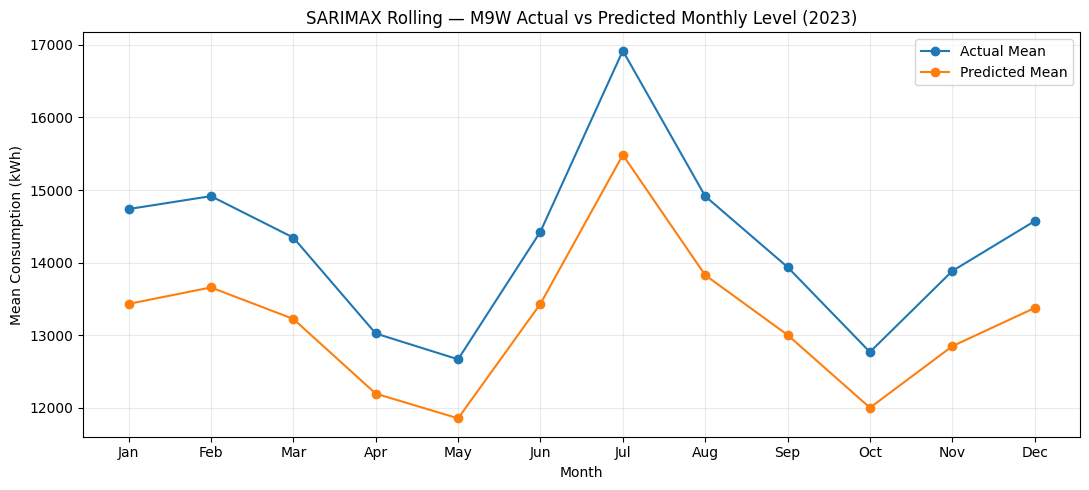

In [40]:
# Plot monthly actual and predicted demand levels for M9W-2023.
plt.figure(figsize=(11, 5))

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["actual_mean"],
    marker="o",
    label="Actual Mean",
)

plt.plot(
    m9w_level_comparison["month_name"],
    m9w_level_comparison["predicted_mean"],
    marker="o",
    label="Predicted Mean",
)

plt.xlabel("Month")
plt.ylabel("Mean Consumption (kWh)")
plt.title(
    "SARIMAX Rolling — M9W Actual vs Predicted Monthly Level (2023)"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### M9W vs remaining FSAs

In [41]:
# Compare M9W with the remaining FSAs during fold_2023.
comparison_2023 = predictions[
    predictions["fold"] == "fold_2023"
].copy()

comparison_2023["group"] = np.where(
    comparison_2023["fsa"] == "M9W",
    "M9W",
    "Other FSAs",
)

m9w_vs_others = (
    comparison_2023
    .groupby(
        "group",
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(m9w_vs_others)


,group,observations,actual_mean,predicted_mean,mae,mape,mean_residual
0,M9W,209664,14259.203217,13195.570255,1223.863238,8.125628,1063.632962
1,Other FSAs,1048320,7977.667853,7955.185081,473.240507,5.803620,22.482773


### Forecast error by temperature band

In [42]:
# Compare forecasting error across temperature bands.
# Temperature is joined at the forecast origin only.
# This is a diagnostic association and does not imply causality.

FEATURE_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "feature_dataset.parquet"
)

feature_data = pd.read_parquet(
    FEATURE_DATASET_PATH,
    columns=[
        "fsa",
        "timestamp",
        "Temp (°C)",
    ],
)

feature_data["timestamp"] = pd.to_datetime(
    feature_data["timestamp"]
)

temperature_lookup = feature_data.rename(
    columns={
        "timestamp": "forecast_origin",
        "Temp (°C)": "temperature",
    }
)

temperature_predictions = predictions.merge(
    temperature_lookup,
    on=[
        "fsa",
        "forecast_origin",
    ],
    how="left",
)

temperature_predictions["temperature_band"] = pd.cut(
    temperature_predictions["temperature"],
    bins=[
        -np.inf,
        -10,
        0,
        10,
        20,
        25,
        30,
        np.inf,
    ],
    labels=[
        "< -10°C",
        "-10 to 0°C",
        "0 to 10°C",
        "10 to 20°C",
        "20 to 25°C",
        "25 to 30°C",
        "> 30°C",
    ],
)

temperature_error = (
    temperature_predictions
    .groupby(
        "temperature_band",
        observed=True,
    )
    .agg(
        observations=("actual", "size"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(temperature_error)


,temperature_band,observations,mae,mape,mean_residual
0,< -10°C,23112,717.268763,6.100565,538.422622
1,-10 to 0°C,329904,546.267702,5.306105,269.366854
2,0 to 10°C,882936,464.757903,5.266516,111.120494
3,10 to 20°C,745992,561.349008,6.360461,89.276514
4,20 to 25°C,410688,799.876351,7.519084,259.369592
5,25 to 30°C,118296,910.944405,7.672230,314.564223
6,> 30°C,7416,996.345398,6.955721,567.123689


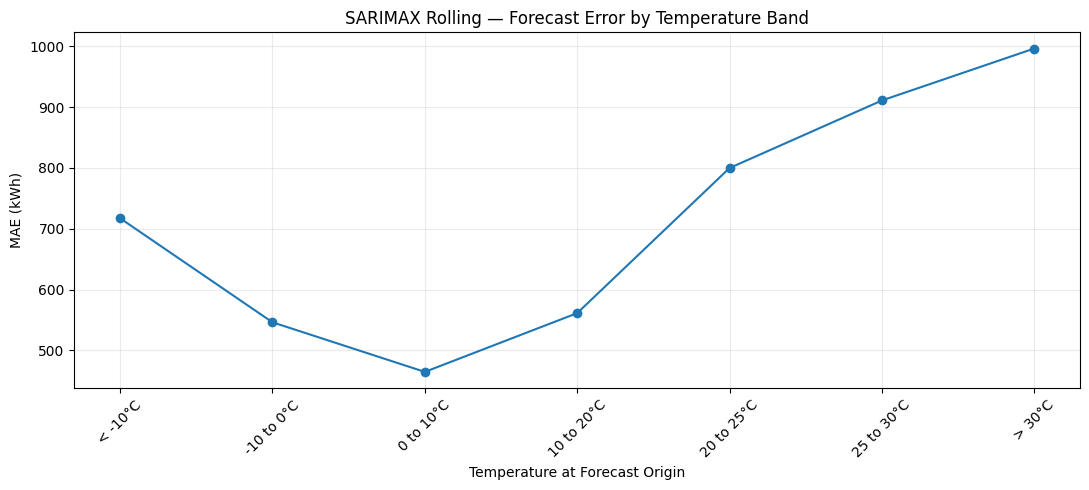

In [43]:
# Plot forecast error by temperature band.
plt.figure(figsize=(11, 5))

plt.plot(
    temperature_error["temperature_band"].astype(str),
    temperature_error["mae"],
    marker="o",
)

plt.xlabel("Temperature at Forecast Origin")
plt.ylabel("MAE (kWh)")
plt.title(
    "SARIMAX Rolling — Forecast Error by Temperature Band"
)
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## SARIMAX-Specific Residual Diagnostics

These plots are particularly relevant for a statistical time-series model because they help identify remaining structure in forecast errors.

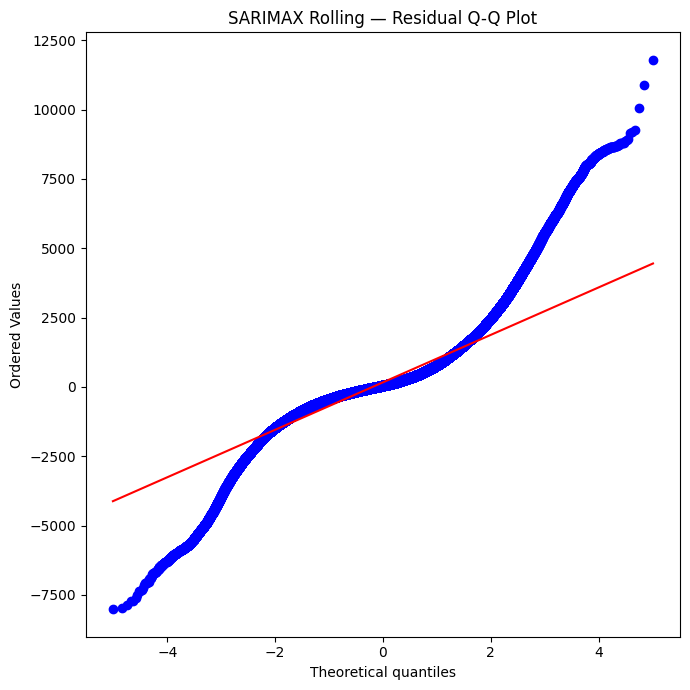

In [44]:
# Q-Q plot of residuals.
from scipy import stats

plt.figure(figsize=(7, 7))

stats.probplot(
    predictions["residual"].dropna(),
    dist="norm",
    plot=plt,
)

plt.title("SARIMAX Rolling — Residual Q-Q Plot")
plt.tight_layout()
plt.show()


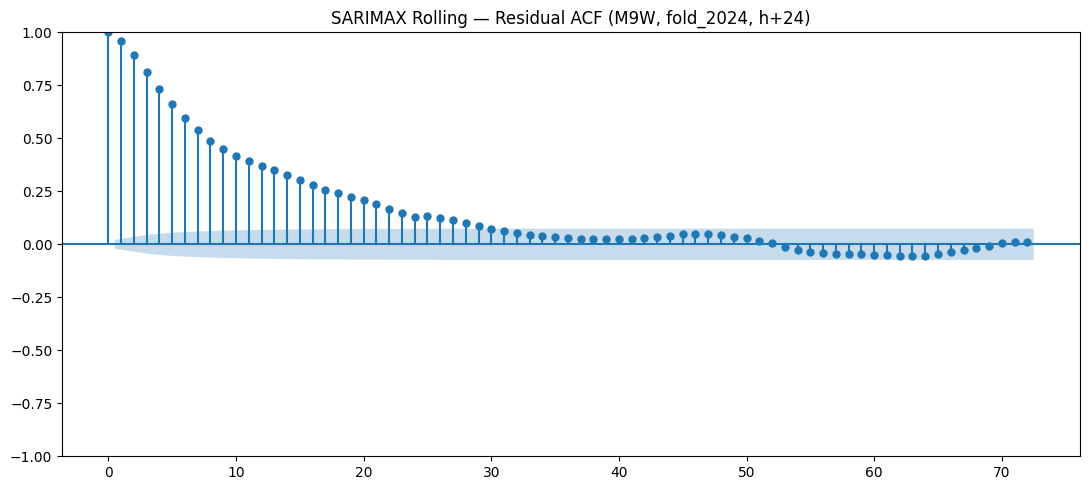

In [45]:
# Residual ACF for a representative validation series.
from statsmodels.graphics.tsaplots import plot_acf

acf_series = (
    predictions
    .query(
        "fold == 'fold_2024' "
        "and fsa == 'M9W' "
        "and horizon == 24"
    )
    .sort_values("forecast_origin")["residual"]
    .dropna()
)

plt.figure(figsize=(11, 5))

plot_acf(
    acf_series,
    lags=72,
    ax=plt.gca(),
)

plt.title(
    "SARIMAX Rolling — Residual ACF "
    "(M9W, fold_2024, h+24)"
)

plt.tight_layout()
plt.show()


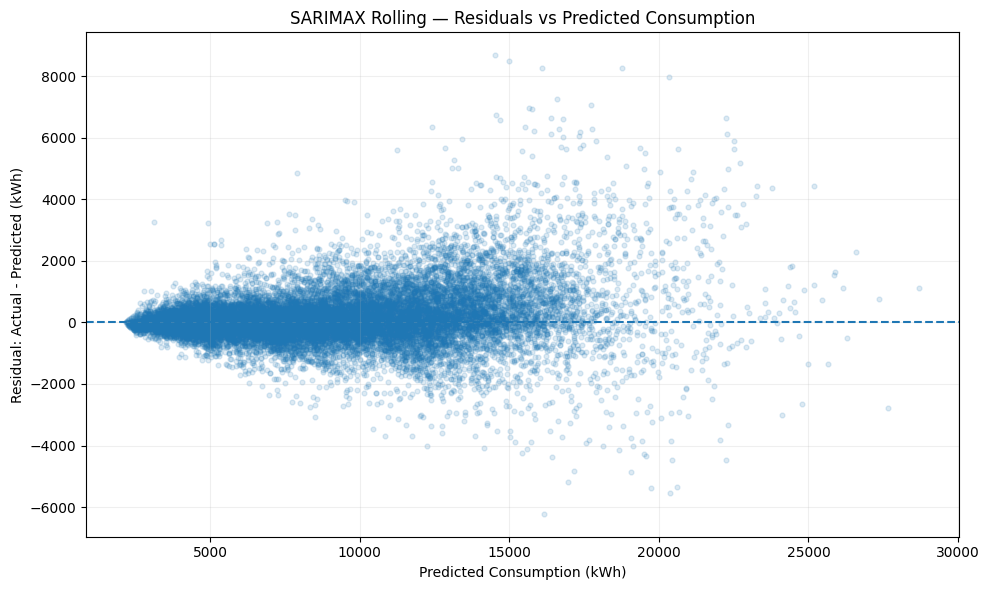

In [46]:
# Residual vs Predicted.
sample = predictions.sample(
    n=min(20000, len(predictions)),
    random_state=42,
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample["predicted"],
    sample["residual"],
    alpha=0.15,
    s=12,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Predicted Consumption (kWh)")
plt.ylabel("Residual: Actual - Predicted (kWh)")
plt.title(
    "SARIMAX Rolling — Residuals vs Predicted Consumption"
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
